# 딥러닝 기반의 텍스트 Detection

### 대표적인 파이썬 OCR 라이브러리
- EasyOCR
- Tesseract
- PaddleOCR


- EasyOCR의 경우 PyTorch 기반 딥러닝 모델로 GPU를 지원함.
- Tesseract의 경우 로컬 환경에서 사용하려면 프로그램을 직접 설치하고, 파이썬 라이브러리를 설치해야 됨.
- 따라서 이 실습은 Colab에서 진행.

In [8]:
%pip install -qqq easyocr==1.7.0 python-bidi==0.4.2 pytesseract

In [9]:
%pip install -qqq openai python-dotenv

In [10]:
!sudo apt install -q tesseract-ocr tesseract-ocr-kor

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-kor is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.


In [11]:
# PaddlePaddle 3.x (CPU 예시)
%pip install paddlepaddle==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

# GPU 예시 (CUDA 11.8용 리눅스 예시, 환경에 맞게 변경)
# %pip install paddlepaddle-gpu==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/

# PaddleOCR 전체 기능
%pip install "paddleocr[all]"


Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/


## 1.EasyOCR
- JaidedAI에서 개발한 오픈소스 OCR 라이브러리
- 80개 이상의 언어를 지원



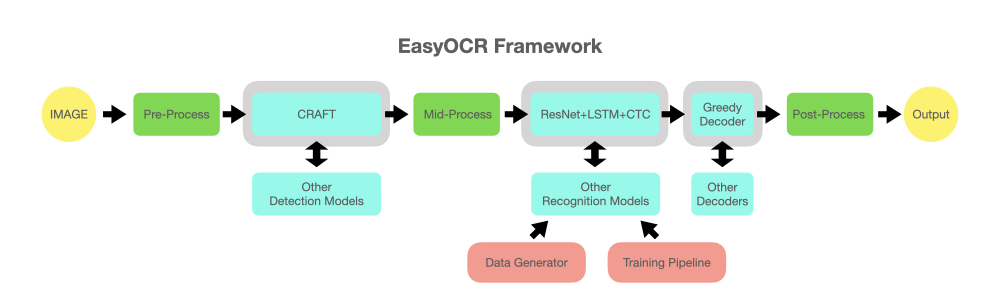

- CRAFT는 *Character Region Awareness for Text detection*의 약자로, 이미지에서 텍스트를 감지하는 데 사용되는 강력한 딥러닝 기반의 텍스트 감지 모델

In [12]:
from IPython.display import Image
Image(url='https://github.com/clovaai/CRAFT-pytorch/raw/master/figures/craft_example.gif')

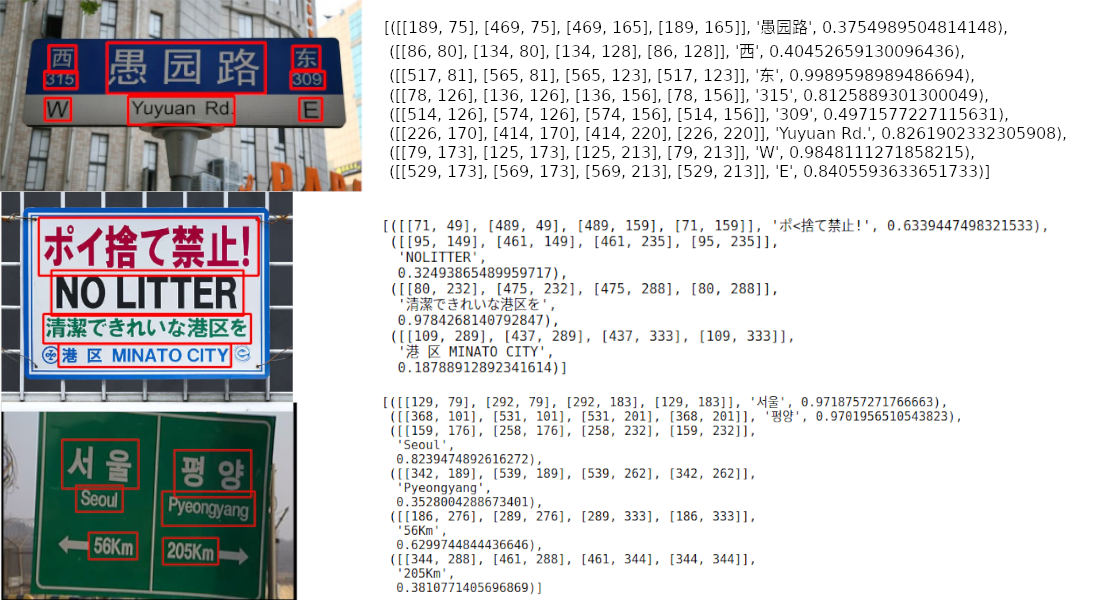

출처: https://github.com/JaidedAI/EasyOCR

In [13]:
import cv2

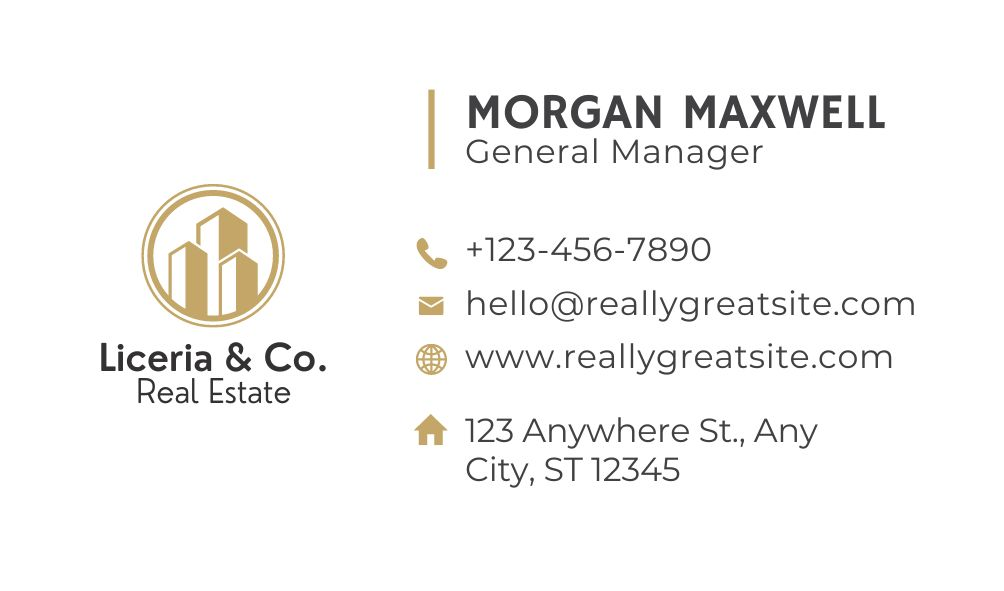

In [14]:
from google.colab.patches import cv2_imshow

# 원본이미지 출력
image_path = 'en_sample.jpg'
image = cv2.imread(image_path)
cv2_imshow(image)

In [15]:
import easyocr

# easyocr 객체 생성
reader = easyocr.Reader(['en'], detect_network = 'craft', gpu=True)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [16]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [17]:
%%time
results= reader.detect(gray_image)

CPU times: user 299 ms, sys: 85.2 ms, total: 384 ms
Wall time: 1.02 s


In [18]:
# 텍스트 영역 바운딩 박스 그리기
easyocr_result = image.copy()

# results[0]
for bbox_group in results[0]:
    for bbox in bbox_group:
        x1, x2, y1, y2 = bbox
        tl = (int(x1), int(y1))
        br = (int(x2), int(y2))

        # 바운딩 박스 그리기
        cv2.rectangle(easyocr_result, tl, br, (0, 255, 0), 2)

In [19]:
# result[1]에는 기울어진 텍스트처럼 사각형 축에 딱 맞지 않는 박스가 들어갈 수 있음
# 각 bbox는 네 꼭짓점 좌표를 가진 다각형 형태

for bbox_group in results[1]:
    for bbox in bbox_group:
        # 네 개의 꼭짓점에서 x와 y 좌표를 각각 분리
        x_coords = [point[0] for point in bbox]
        y_coords = [point[1] for point in bbox]

        # 상단 왼쪽 좌표 (tl)와 하단 오른쪽 좌표 (br) 계산
        x1, y1 = int(min(x_coords)), int(min(y_coords))
        x2, y2 = int(max(x_coords)), int(max(y_coords))

        tl = (x1, y1)  # 상단 왼쪽 좌표
        br = (x2, y2)  # 하단 오른쪽 좌표

        # 바운딩 박스 그리기
        cv2.rectangle(easyocr_result, tl, br, (0, 255, 0), 2)

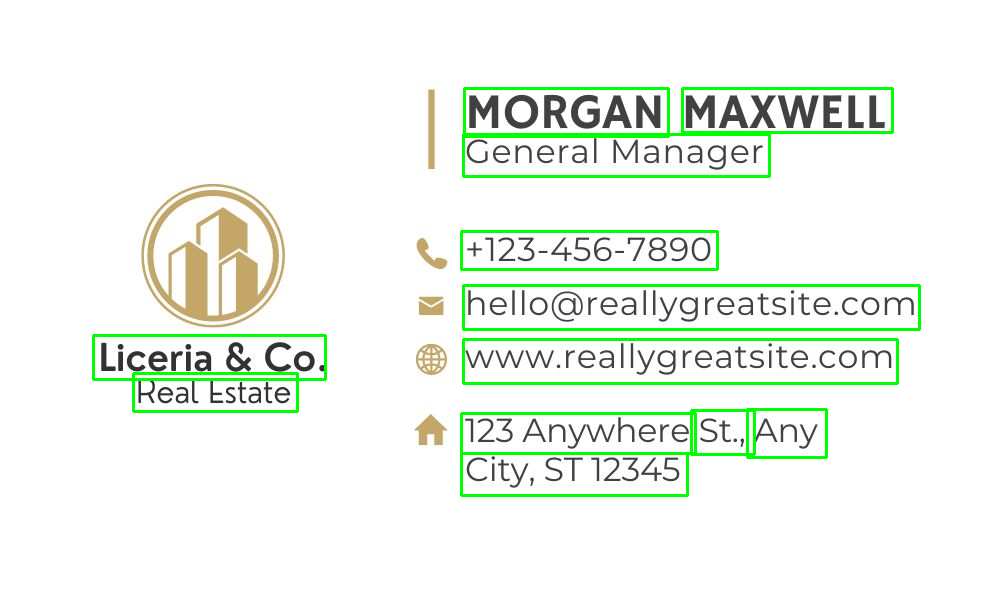

In [20]:
# 텍스트 검출 결과 초록색 박스가 글자 주변을 잘 감싸고 있으면 detection 단계 잘 동작.
cv2_imshow(easyocr_result)

In [21]:
import PIL
PIL.Image.ANTIALIAS = PIL.Image.LANCZOS

In [22]:
# reader.readtext : 텍스트 위치 검출과 글자 인식을 한번에 수행
results = reader.readtext(image_path)
results

[([[np.int32(464), np.int32(88)],
   [np.int32(668), np.int32(88)],
   [np.int32(668), np.int32(136)],
   [np.int32(464), np.int32(136)]],
  'MORGAN',
  np.float64(0.9901020491516912)),
 ([[np.int32(682), np.int32(88)],
   [np.int32(892), np.int32(88)],
   [np.int32(892), np.int32(132)],
   [np.int32(682), np.int32(132)]],
  'MAXWELL',
  np.float64(0.9984390924720369)),
 ([[np.int32(463), np.int32(134)],
   [np.int32(769), np.int32(134)],
   [np.int32(769), np.int32(176)],
   [np.int32(463), np.int32(176)]],
  'General Manager',
  np.float64(0.9999107380606019)),
 ([[np.int32(461), np.int32(231)],
   [np.int32(717), np.int32(231)],
   [np.int32(717), np.int32(269)],
   [np.int32(461), np.int32(269)]],
  '+123-456-7890',
  np.float64(0.860822325824132)),
 ([[np.int32(463), np.int32(285)],
   [np.int32(919), np.int32(285)],
   [np.int32(919), np.int32(329)],
   [np.int32(463), np.int32(329)]],
  'hello@reallygreatsite.com',
  np.float64(0.8320879850738663)),
 ([[np.int32(93), np.int32(33

In [23]:
# easyocr 결과가 results 변수에 들어있다고 가정
texts = [text for (_, text, _) in results]

print("추출된 텍스트:")
for t in texts:
    print(t)

추출된 텍스트:
MORGAN
MAXWELL
General Manager
+123-456-7890
hello@reallygreatsite.com
Liceria & Co_
wwW.reallygreatsite.com
Real Estate
123 Anywhere
City, ST 12345
St,
Any


In [24]:
# 결과 출력
# OCR 결과를 텍스와 신뢰도까지 함께 출력
# 실무 confidence가 너무 낮은 결과는 자동으로 처리하지 않고, 검수 대상으로 보냄.
for bbox, text, prob in results:
    print(f"인식된 텍스트: {text} (신뢰도: {prob:.2f})")

인식된 텍스트: MORGAN (신뢰도: 0.99)
인식된 텍스트: MAXWELL (신뢰도: 1.00)
인식된 텍스트: General Manager (신뢰도: 1.00)
인식된 텍스트: +123-456-7890 (신뢰도: 0.86)
인식된 텍스트: hello@reallygreatsite.com (신뢰도: 0.83)
인식된 텍스트: Liceria & Co_ (신뢰도: 0.74)
인식된 텍스트: wwW.reallygreatsite.com (신뢰도: 0.70)
인식된 텍스트: Real Estate (신뢰도: 0.76)
인식된 텍스트: 123 Anywhere (신뢰도: 0.95)
인식된 텍스트: City, ST 12345 (신뢰도: 0.97)
인식된 텍스트: St, (신뢰도: 0.90)
인식된 텍스트: Any (신뢰도: 1.00)


## 2.Tesseract
- 1985년에 Hewlett-Packard Lab과 Hewlett-Packard Co에서 개발한 오픈소스 OCR 라이브러리
- 100개 이상의 언어를 지원

In [25]:
import pytesseract
import csv
from io import StringIO

In [26]:
text = pytesseract.image_to_data(gray_image, lang='eng')

In [27]:
def parse_text_to_dict(text):
    # StringIO 객체를 사용하여 문자열을 파일처럼 처리
    csv_file = StringIO(text)

    # csv.DictReader를 사용하여 CSV 형식의 데이터를 읽음
    reader = csv.DictReader(csv_file, delimiter="\t")

    # 결과를 저장할 리스트
    result = []

    # 각 행을 순회하며 딕셔너리로 변환
    for row in reader:
        # 모든 키-값 쌍을 순회하며 값을 적절한 타입으로 변환
        parsed_row = {}
        for key, value in row.items():
            if key in ["level", "page_num", "block_num", "par_num", "line_num", "word_num"]:
                parsed_row[key] = int(value)
            elif key in ["left", "top", "width", "height"]:
                parsed_row[key] = int(value)
            elif key == "conf":
                parsed_row[key] = int(value) if value != "-1" else -1
            else:
                parsed_row[key] = value

        result.append(parsed_row)

    return result

In [28]:
# TSV 문자열을 딕셔너리 리스트로 반환
parsed_data = parse_text_to_dict(text)
parsed_data

[{'level': 1,
  'page_num': 1,
  'block_num': 0,
  'par_num': 0,
  'line_num': 0,
  'word_num': 0,
  'left': 0,
  'top': 0,
  'width': 1004,
  'height': 591,
  'conf': -1,
  'text': ''},
 {'level': 2,
  'page_num': 1,
  'block_num': 1,
  'par_num': 0,
  'line_num': 0,
  'word_num': 0,
  'left': 101,
  'top': 342,
  'width': 225,
  'height': 62,
  'conf': -1,
  'text': ''},
 {'level': 3,
  'page_num': 1,
  'block_num': 1,
  'par_num': 1,
  'line_num': 0,
  'word_num': 0,
  'left': 101,
  'top': 342,
  'width': 225,
  'height': 62,
  'conf': -1,
  'text': ''},
 {'level': 4,
  'page_num': 1,
  'block_num': 1,
  'par_num': 1,
  'line_num': 1,
  'word_num': 0,
  'left': 101,
  'top': 342,
  'width': 225,
  'height': 30,
  'conf': -1,
  'text': ''},
 {'level': 5,
  'page_num': 1,
  'block_num': 1,
  'par_num': 1,
  'line_num': 1,
  'word_num': 1,
  'left': 101,
  'top': 343,
  'width': 110,
  'height': 29,
  'conf': 92,
  'text': 'Liceria'},
 {'level': 5,
  'page_num': 1,
  'block_num': 1,
 

In [29]:
texts = [item['text'] for item in parsed_data if item['text'].strip() != '']

print("추출된 텍스트:")
for t in texts:
    print(t)

추출된 텍스트:
Liceria
&
Co.
Real
Estate
MORGAN
MAXWELL
General
Manager
&
+123-456-7890
=
hello@reallygreatsite.com
®
www.reallygreatsite.com
f
123
Anywhere
St.,
Any
City,
ST
12345


In [30]:
# 텍스트 영역 바운딩 박스 그리기
tesseract_result = image.copy()
for item in parsed_data:
    text = item["text"]

    if text == "":
        continue

    # 바운딩 박스 좌표 추출
    left = item["left"]
    top = item["top"]
    width = item["width"]
    height = item["height"]

    # 바운딩 박스의 좌상단과 우하단 좌표 계산
    tl = (left, top)
    br = (left + width, top + height)

    # 바운딩 박스 그리기
    cv2.rectangle(tesseract_result, tl, br, (0, 255, 0), 2)

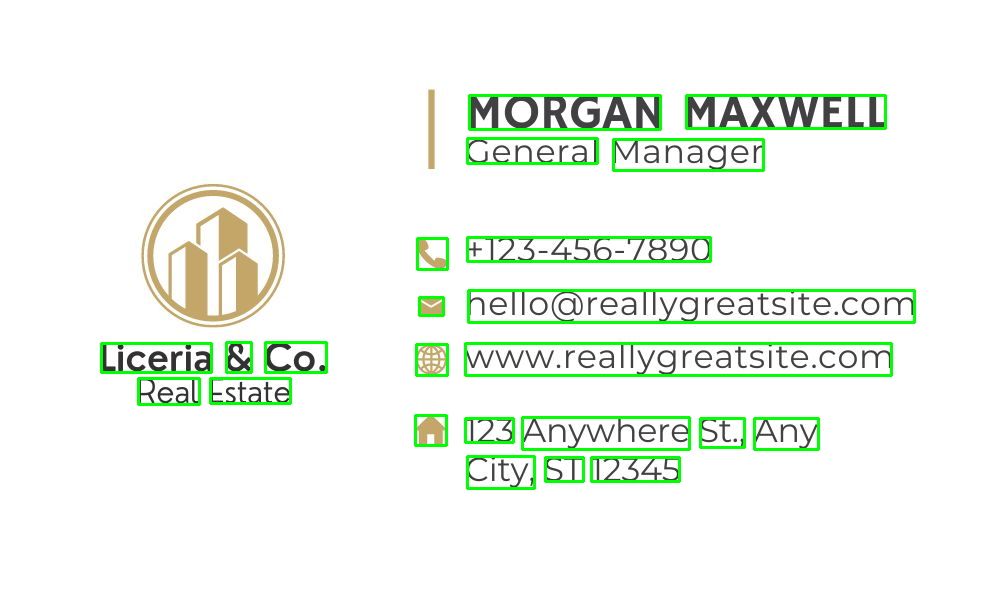

In [31]:
cv2_imshow(tesseract_result)

## 3.PaddleOCR
- Baidu에서 개발한 경량화된 오픈소스 OCR 라이브러리
- 80개 이상의 언어를 지원

In [33]:
from paddleocr import PaddleOCR
from PIL import Image

In [34]:
from IPython.display import Image

Image(url='https://github.com/PaddlePaddle/PaddleOCR/releases/download/v2.8.0/demo.gif')

In [45]:
import os
from pathlib import Path
import cv2
import numpy as np

def cv2_imread_korean(path, flags=cv2.IMREAD_COLOR):
    """한글/공백이 포함된 경로도 안정적으로 읽는 OpenCV 이미지 로더입니다."""
    path = str(path)

    # Windows OpenCV는 유니코드 파일명을 못 읽는 경우가 있어 우회합니다.
    if os.name == "nt":
        data = np.fromfile(path, dtype=np.uint8)
        if data.size == 0:
            return None
        return cv2.imdecode(data, flags)

    return cv2.imread(path, flags)


def resolve_image_path(filename):
    """Colab 루트, 현재 폴더, data 폴더 중 실제 존재하는 이미지 경로를 찾아줍니다."""
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("/content") / filename,
    ]

    for candidate in candidates:
        if candidate.exists():
            return str(candidate)

    # 파일이 아직 업로드되지 않은 Colab 상황도 있으므로 원래 이름을 반환합니다.
    return filename


def paddle_ocr_input(path):
    """PaddleOCR 입력을 준비합니다. Windows 한글 경로 문제를 만나면 이미지 배열 입력으로 우회합니다."""
    if os.name == "nt":
        image = cv2_imread_korean(path)
        return image if image is not None else path
    return path

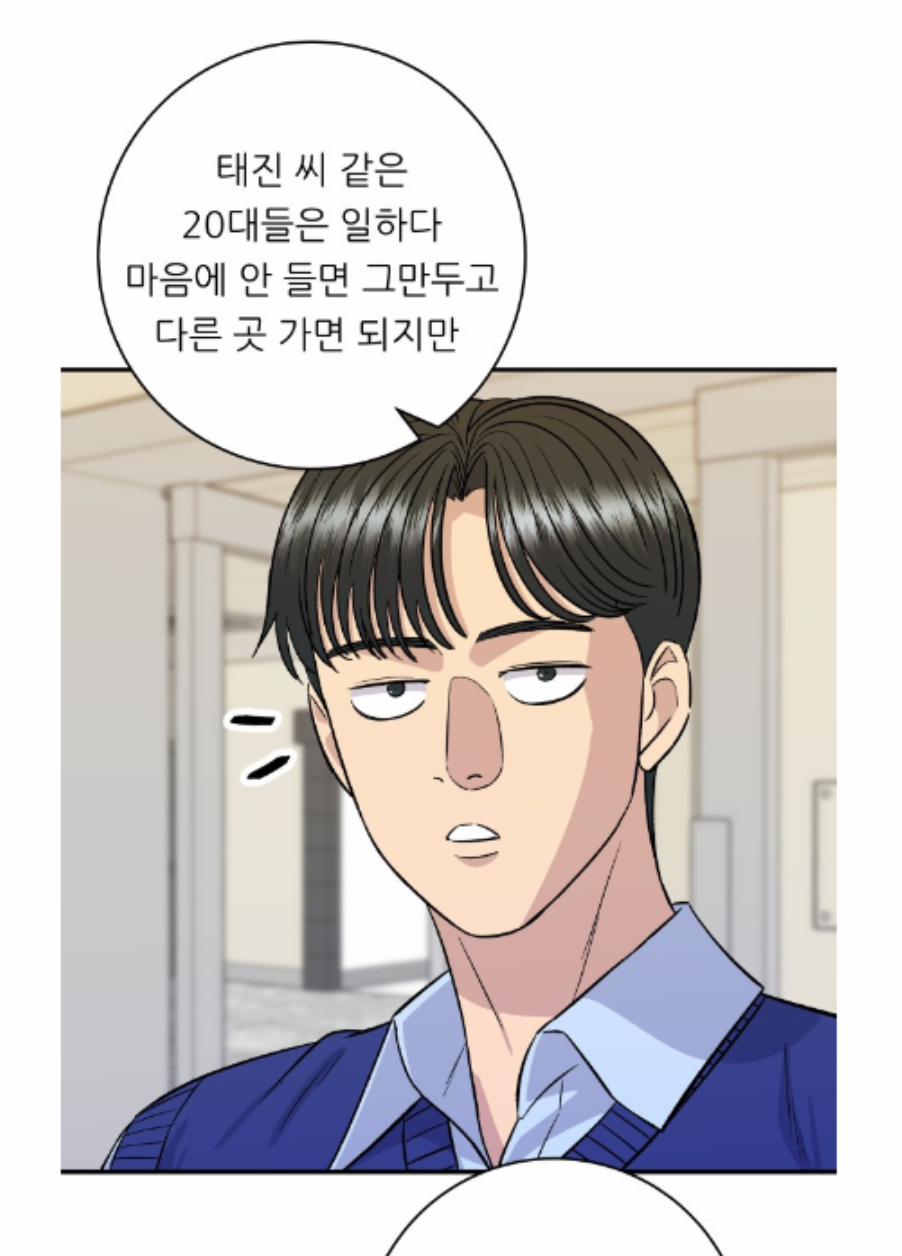

In [46]:
img_path = resolve_image_path('webtoon.png')
img = cv2_imread_korean(img_path)

# 정상적으로 읽혔는지 확인
cv2_imshow(img)

In [47]:
# paddleocr 객체 생성
paddle_reader = PaddleOCR(
    use_doc_orientation_classify=False, # 문서 전체가 회전되어 있는지 분류하는 모델 -> False
    use_doc_unwarping=False,            # 문서가 휘거나 왜곡된 경우 펴주는 보정 모델 -> False
    use_textline_orientation=False,     # 텍스트 줄 단위 방향(세로쓰기나 회전된 텍스트가 많으면 True가 도움됨.)
    lang='korean',
    device='gpu'
)

Creating model: ('PP-OCRv5_server_det', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
The specified device (GPU) is not available! Switching to CPU instead.
Creating model: ('korean_PP-OCRv5_mobile_rec', None, None)
Using official model (korean_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/korean_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

The specified device (GPU) is not available! Switching to CPU instead.


In [51]:
result1 = paddle_reader.predict(paddle_ocr_input(img_path))

In [ ]:
for res in result1:
    res.print()
    res.save_to_img('output')
    res.save_to_json('output')

In [ ]:
page = result1[0]
page

In [54]:
# OCR 결과에는 특수문자, 깨진 문자, 불필요한 기호가 섞일 수 있음
# 정규식을 사용해 업무에 필요한 문자를 남기는 간단한 후처리 함수를 만들어서 사용
import re

def keep_korean(s: str) -> str:
    # 한글, 숫자, 공백, 기본 문장부호만 남기는 예시
    return re.sub(r"[^ 가-힣0-9.,?!~…·\-\(\)\[\]{}“”\"'’‘:;/]", "", s)

cleaned = " ".join(keep_korean(t) for t in page["rec_texts"])
print(cleaned)

태진씨 같은 20대들은 일하다 마음에 안 들면 그만두고 다른 곳 가면 되지만


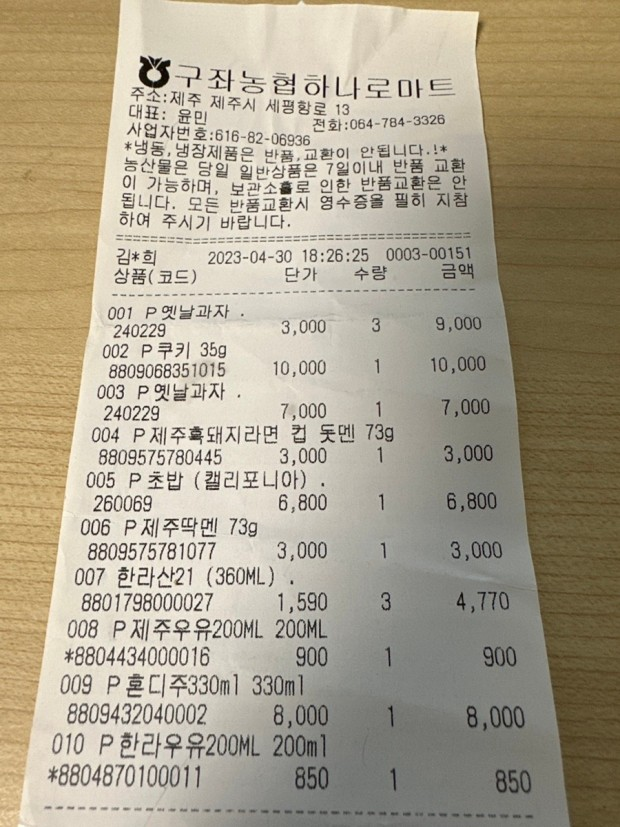

In [55]:
# 두 번째 예시는 영수증 이미지
img_path2 = resolve_image_path('영수증.jpg')
img2 = cv2_imread_korean(img_path2)
cv2_imshow(img2)

In [56]:
result2 = paddle_reader.predict(paddle_ocr_input(img_path2))

In [57]:
cleaned = " ".join(keep_korean(t) for t in result2[0]["rec_texts"])
print(cleaned)

구좌농협하나로마트 주소:제주 제주시 세평항로13 대표: 윤민 사업자번호:616-82-06936 전화:064-784-3326 농산물리장세일반품곤7일이내 박물 교항 이가능하며, 보관장로 인한 반품교화은 안 됩니다.모는 반품교환시 영수증을 필히 지참 하여 주시기 바랍니다 김희 2023-04-30 18:26:25 0003-00151 상품(코드) 단가 수량 금액 001옛날과자. 240229 3,000 3 9,000 002 쿠키 35 8809068351015 10,000 1 10,000 003 옛날과자. 240229 7,000 1 7,000 004 제주혹돼지라면 컵 듯멘 73 8809575780445 3,000 1 3,000 005 초밥 (캘리포니아). 260069 6,800 1 6,800 006 제주딱멘 73 8809575781077 3,000 1 3,000 007 한라산21 (360). 8801798000027 1,590 3 4,770 008 제주우유200200 8804434000016 900 1 900 009혼디주330]3301 8809432040002 8,000 1 8,000 010  한라우유2002001 8804870100011 850 1 850


### 어떤 OCR를 선택하는게 좋을까?
- 빠르게 실험하고 싶다 : EasyOCR. 코드가 짧고 가볍고, 결과 형식도 단순
- 스캔 문서가 많고 서버 비용을 낮추고 싶다. : Tesseract가 좋음. 단, 이미지 전처리와 언어 데이터 설치를 잘 관리해야됨.
- 한국어 문서/영수증/복잡한 이미지 : PaddleOCR이 좋음. 설치는 무겁지만 결과 저장, 시각화, 문서 처리 옵션이 풍부